In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
from sklearn.datasets import make_regression

In [16]:
X,y = make_regression(n_samples=1000,n_features=2,n_targets=1,noise=3.0)

In [17]:
X

array([[-1.42607959, -0.44136889],
       [ 0.60816156,  0.11920794],
       [-0.90667318, -1.50057692],
       ...,
       [ 1.88617549, -0.98191004],
       [-0.54175287,  0.13419299],
       [ 1.31240432, -1.53022103]], shape=(1000, 2))

In [18]:
y

array([-9.89638319e+01,  4.22599807e+01, -9.58978903e+01, -1.45011952e+02,
        7.11292353e+01,  6.59247015e+01, -5.61028516e+01,  6.00744067e+01,
        6.66678587e+00,  2.93775134e+00,  3.52912468e+01, -5.84672326e+00,
       -7.39879001e+01, -1.67133026e+02,  2.85800587e+01,  4.81842612e+01,
       -9.92358650e+00, -7.59299574e+01, -7.93378524e+01,  1.33492262e+02,
        1.85821644e+01, -3.23475102e+01, -5.66894845e+01,  9.23496772e+00,
       -4.46803599e+01, -3.29859135e+01, -1.87268056e+01, -2.52954524e+01,
        1.14220270e+02, -1.32233424e+01,  1.16274522e+02,  1.02251791e+01,
       -8.41243819e+01, -4.87815215e+01,  9.96203643e+01,  1.41309679e+02,
       -9.97970541e+01, -4.77572062e+01, -4.48494157e+01,  3.46944408e+01,
        1.20158688e+02,  2.01571825e+01,  2.24025701e+01, -1.10935570e+02,
       -5.72100746e+01,  1.44902448e+01, -7.35108583e+01, -6.31384722e+01,
        8.96305955e+00,  9.99305669e+01, -2.32468947e+01,  1.25777501e+02,
        3.61130979e+01, -

In [19]:
pd.DataFrame(X)[0]

0     -1.426080
1      0.608162
2     -0.906673
3     -1.773200
4      0.443992
         ...   
995   -1.103047
996   -1.431706
997    1.886175
998   -0.541753
999    1.312404
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

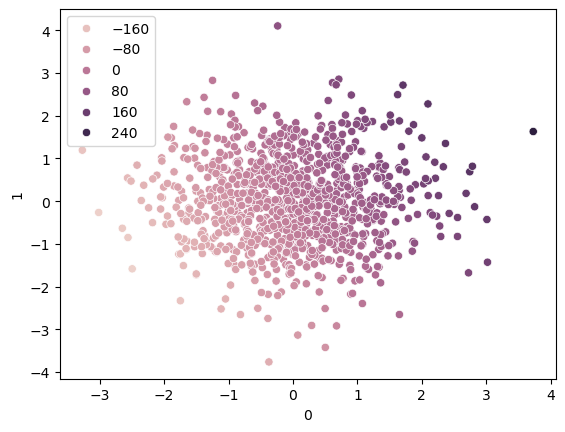

In [20]:
sns.scatterplot(x=pd.DataFrame(X)[0],y =pd.DataFrame(X)[1],hue=y)

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [22]:
from sklearn.svm import SVR

In [23]:
svr = SVR(kernel = 'linear')

In [24]:
svr.fit(X_train,y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [26]:
svr.coef_

array([[61.15027565, 27.15205408]])

In [27]:
y_pred = svr.predict(X_test)

In [28]:
y_pred

array([ 2.94412661e+01, -3.97703589e+01,  5.41027312e+01, -9.86117173e+01,
       -1.26313581e+02,  4.26286992e+01, -4.78334370e+01, -9.04748365e+01,
       -2.02284207e+01,  2.81180518e+01,  2.09238275e+01, -1.41863272e+01,
       -7.56065783e+01, -4.36054313e+01, -1.14440695e+02,  9.37357844e+00,
       -7.19636342e+01, -6.19519048e+01,  7.83140892e+00, -1.35005961e+01,
        1.66994115e+02, -8.47254306e+01,  4.13254505e+01, -7.14036513e+01,
        1.81370805e+01, -4.89932298e-01, -2.53985060e+01, -7.27653486e+01,
        1.92059170e+01,  4.22409913e+01,  4.65529875e+01, -2.91095043e+01,
       -1.15359612e+02,  1.09042098e+02, -4.40661700e+00,  4.75281380e+01,
        3.48445954e+01,  6.26762148e+01, -3.27830254e+01, -5.95784675e+01,
        5.81168058e+01, -5.90117057e+01,  3.34462963e+01,  3.25349381e+01,
        6.94308836e+01, -4.79907761e+01, -4.13298308e+01,  4.00216998e+01,
       -3.35746113e+01,  3.61710406e+01,  2.53736558e+01,  7.63226327e+01,
       -1.01609749e+02,  

In [29]:
from sklearn.metrics import r2_score

In [30]:
print(r2_score(y_test,y_pred))

0.9980531182713713


# Hyper parameter tunning

In [33]:
from sklearn.model_selection import GridSearchCV

In [39]:
parameter = {
    'C' : [0.1,1,10,100,1000],
    'gamma' : [1,0.1,0.01,0.001,0.0001],
    'kernel' : ['linear'],
    'epsilon' : [0.1,0.2,0.3]
}

In [40]:
grid = GridSearchCV(SVR(),param_grid = parameter,refit = True,cv=5,verbose=3)

In [41]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV 1/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.900 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.890 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.903 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.903 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.906 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.900 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.890 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.903 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.903 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.906 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamma

,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'epsilon': [0.1, 0.2, ...], 'gamma': [1, 0.1, ...], 'kernel': ['linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [43]:
grid.best_params_

{'C': 1000, 'epsilon': 0.3, 'gamma': 1, 'kernel': 'linear'}

In [44]:
y_pred = grid.predict(X_test)
print(r2_score(y_test,y_pred))

0.9980799640383375
